<a href="https://colab.research.google.com/github/fauziah-azzhr/PertemuanKeenam/blob/main/TugasRestorasiCitra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving mgg6.jpg to mgg6 (2).jpg


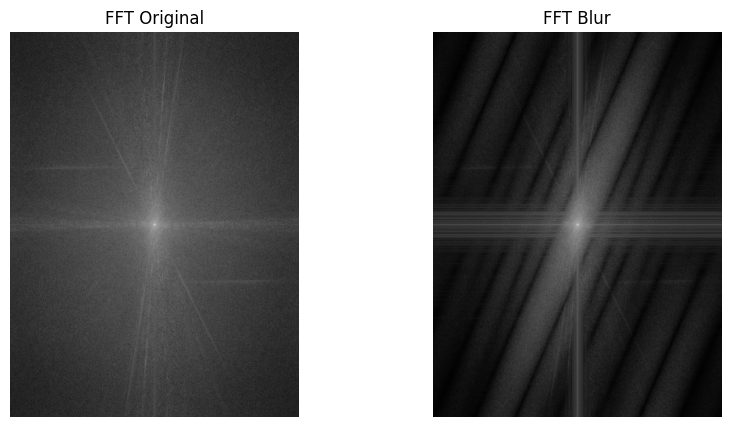

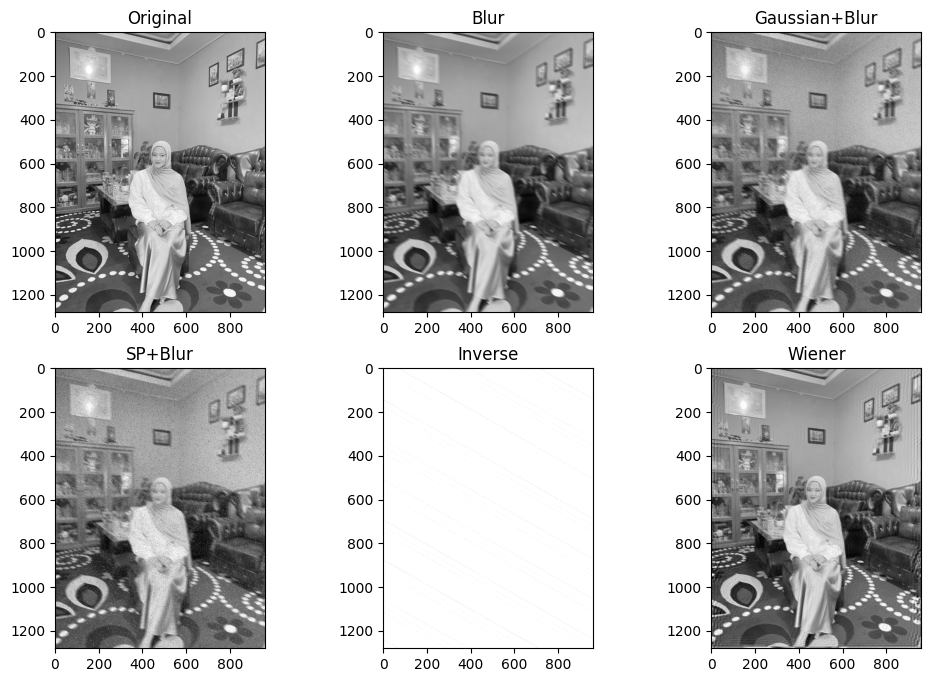


=== HASIL EVALUASI ===
        Skenario           Metode     PSNR     MSE    SSIM   Waktu
0           Blur          Inverse   5.5589  0.2780  0.4237  0.1516
1           Blur           Wiener  16.2205  0.0239  0.4190  0.1541
2           Blur  Lucy-Richardson  21.4127  0.0072  0.7497  1.4284
3  Gaussian+Blur          Inverse   5.5566  0.2782  0.4443  0.1308
4  Gaussian+Blur           Wiener  10.7046  0.0850  0.0113  0.1331
5  Gaussian+Blur  Lucy-Richardson  18.0595  0.0156  0.2146  1.6809
6        SP+Blur          Inverse   5.5613  0.2779  0.4232  0.1734
7        SP+Blur           Wiener  16.2922  0.0235  0.4138  0.1950
8        SP+Blur  Lucy-Richardson  21.2435  0.0075  0.7267  1.8085


In [ ]:
# IMPORT LIBRARY
# ==========================================================
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import time

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import mean_squared_error as mse
from skimage.metrics import structural_similarity as ssim
from scipy.signal import convolve2d
from skimage.restoration import richardson_lucy

# UPLOAD GAMBAR (GOOGLE COLAB)
# ==========================================================
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

# LOAD GAMBAR
# ==========================================================
img = cv2.imread(filename, 0)

if img is None:
    raise ValueError("Gambar tidak ditemukan!")

img = img.astype(np.float32) / 255.0

# FUNCTION PSF (MOTION BLUR)
# ==========================================================
def motion_psf(length, angle):
    psf = np.zeros((length, length))
    center = length // 2

    for i in range(length):
        x = int(center + (i - center) * np.cos(np.deg2rad(angle)))
        y = int(center + (i - center) * np.sin(np.deg2rad(angle)))
        if 0 <= x < length and 0 <= y < length:
            psf[y, x] = 1

    psf /= psf.sum()
    return psf

psf = motion_psf(15, 30)

# DEGRADASI
# ==========================================================
blur = convolve2d(img, psf, mode='same', boundary='symm')

# Gaussian noise
gaussian = blur + np.random.normal(0, 20/255.0, img.shape)
gaussian = np.clip(gaussian, 0, 1)

# Salt & Pepper noise
sp = blur.copy()
prob = 0.05
rnd = np.random.rand(*img.shape)
sp[rnd < prob/2] = 0
sp[rnd > 1 - prob/2] = 1

# INVERSE FILTER
# ==========================================================
def inverse_filter(img, psf):
    H = np.fft.fft2(psf, s=img.shape)
    G = np.fft.fft2(img)

    eps = 1e-6
    H = np.where(np.abs(H) < eps, eps, H)

    F = G / H
    result = np.abs(np.fft.ifft2(F))

    return np.clip(result, 0, 1)

# WIENER FILTER
# ==========================================================
def wiener_filter(img, psf, K=0.01):
    H = np.fft.fft2(psf, s=img.shape)
    G = np.fft.fft2(img)

    H_conj = np.conj(H)
    denom = (np.abs(H)**2 + K)

    F = (H_conj / denom) * G
    result = np.abs(np.fft.ifft2(F))

    return np.clip(result, 0, 1)

# EVALUASI
# ==========================================================
def evaluate(original, restored):
    return (
        psnr(original, restored, data_range=1),
        mse(original, restored),
        ssim(original, restored, data_range=1)
    )

results = []

# PROSES SEMUA SKENARIO
# ==========================================================
scenarios = {
    "Blur": blur,
    "Gaussian+Blur": gaussian,
    "SP+Blur": sp
}

for name, degraded in scenarios.items():

    # Khusus SP → median filter dulu
    if name == "SP+Blur":
        degraded = cv2.medianBlur((degraded*255).astype(np.uint8), 3) / 255.0

    # Inverse
    start = time.time()
    inv = inverse_filter(degraded, psf)
    t_inv = time.time() - start
    p, m, s = evaluate(img, inv)
    results.append([name, "Inverse", p, m, s, t_inv])

    # Wiener
    start = time.time()
    wnr = wiener_filter(degraded, psf, K=0.01)
    t_w = time.time() - start
    p, m, s = evaluate(img, wnr)
    results.append([name, "Wiener", p, m, s, t_w])

    # Lucy-Richardson
    start = time.time()
    lr = richardson_lucy(degraded, psf, num_iter=10)
    lr = np.clip(lr, 0, 1)
    t_lr = time.time() - start
    p, m, s = evaluate(img, lr)
    results.append([name, "Lucy-Richardson", p, m, s, t_lr])

# FFT VISUALISASI
# ==========================================================
def show_fft(image, title):
    f = np.fft.fftshift(np.fft.fft2(image))
    mag = np.log(1 + np.abs(f))
    plt.imshow(mag, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
show_fft(img, "FFT Original")

plt.subplot(1,2,2)
show_fft(blur, "FFT Blur")
plt.show()

# VISUALISASI HASIL
# ==========================================================
plt.figure(figsize=(12,8))

plt.subplot(2,3,1); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.subplot(2,3,2); plt.imshow(blur, cmap='gray'); plt.title("Blur")
plt.subplot(2,3,3); plt.imshow(gaussian, cmap='gray'); plt.title("Gaussian+Blur")
plt.subplot(2,3,4); plt.imshow(sp, cmap='gray'); plt.title("SP+Blur")
plt.subplot(2,3,5); plt.imshow(inv, cmap='gray'); plt.title("Inverse")
plt.subplot(2,3,6); plt.imshow(wnr, cmap='gray'); plt.title("Wiener")

plt.show()

# TABEL HASIL
# ==========================================================
df = pd.DataFrame(results, columns=["Skenario","Metode","PSNR","MSE","SSIM","Waktu"])

print("\n=== HASIL EVALUASI ===")
print(df.round(4))